# Lab 5: Transfer learning.

Thanks to their capability to learn generalizable descriptors directly from images, deep Convolutional Neural Networks (CNNs) seem the ideal solution to most pattern recognition problems. On the other hand, to learn the image representation, CNNs need huge sets of annotated samples that are unfeasible in many every-day scenarios. This is the case, for example, of Computer-Aided Diagnosis (CAD) systems for digital pathology, where additional challenges are
posed by the high variability of the cancerous tissue characteristics.
In this notebooks you are going to implement 4 different training paradigms leveraging CNNs:


1.   Training from scratch
2.   Features extractor followed by SVM
3.   Fine tuning



---



**Final Results on Test Accuracy:**


| Paradigm | Test Acuracy |
| ------------ | ----- |
| Scratch | 0.75 |
| Feature Extractor + SVM | 0.83 |
| Fine Tuning | 0.95 |



# Import and settings

In [1]:
import os
import cv2
import glob
import numpy as np
import seaborn as sns
import tensorflow as tf
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
from keras.applications.vgg16 import VGG16
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from scipy.stats import reciprocal

In [6]:
!git clone https://github.com/frpnz/dataset-BIOSTEC2018.git

Cloning into 'dataset-BIOSTEC2018'...
remote: Enumerating objects: 13518, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 13518 (delta 1), reused 6 (delta 1), pack-reused 13512 (from 1)
Receiving objects: 100% (13518/13518), 1.87 GiB | 35.07 MiB/s, done.
Resolving deltas: 100% (1/1), done.
Updating files: 100% (13501/13501), done.


In [2]:
ROOTDIR_DATASET = "/content/dataset-BIOSTEC2018/crc_images"
IMAGE_SIZE = 32
NUM_CLASSES = 3
NUM_IMGS = 9000

## Utils

In [3]:
def seaborn_cm(cm, ax, tick_labels, fontsize=14, title=None, sum_actual="over_columns",
               xrotation=0, yrotation=0):
    """
    Function to plot a confusion matrix
    """
    from matplotlib import cm as plt_cmap
    group_counts = ["{:0.0f}".format(value) for value in cm.flatten()]
    if sum_actual == "over_columns":
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    elif sum_actual == "over_rows":
        cm = cm.astype('float') / cm.sum(axis=0)[:, np.newaxis]
    else:
        print("sum_actual must be over_columns or over_rows")
        exit()
    cm = np.nan_to_num(cm)
    mean_acc = np.mean(np.diag(cm)[cm.sum(axis=1) != 0])
    std_acc = np.std(np.diag(cm))
    group_percentages = ["{:0.0f}".format(value*100) for value in cm.flatten()]
    cm_labels = [f"{c}\n{p}%" for c, p in zip(group_counts, group_percentages)]
    cm_labels = np.asarray(cm_labels).reshape(len(tick_labels), len(tick_labels))
    sns.heatmap(cm,
                ax=ax,
                annot=cm_labels,
                fmt='',
                cbar=False,
                cmap=plt_cmap.Greys,
                linewidths=1, linecolor='black',
                annot_kws={"fontsize": fontsize},
                xticklabels=tick_labels,
                yticklabels=tick_labels)
    ax.set_yticklabels(ax.get_yticklabels(), size=fontsize, rotation=yrotation)
    ax.set_xticklabels(ax.get_xticklabels(), size=fontsize, rotation=xrotation)
    if title:
        title = f"{title}\nMean accuracy {mean_acc * 100:.1f} +- {std_acc * 100:.1f}"
    else:
        title = f"Mean accuracy {mean_acc * 100:.1f} +- {std_acc * 100:.1f}"
    ax.set_title(title)
    if sum_actual == "over_columns":
        ax.set_ylabel("Actual")
        ax.set_xlabel("Predicted")
    else:
        ax.set_ylabel("Predicted")
        ax.set_xlabel("Actual")
    ax.axis("off")

# Assignment #1: create two tensorflow dataset for train and test.
Leverage the API [tf.keras.utils.image_dataset_from_directory](https://www.tensorflow.org/api_docs/python/tf/keras/utils/image_dataset_from_directory).

In [39]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{ROOTDIR_DATASET}/train",
    labels='inferred',
    label_mode='int',
    class_names=["AC", "AD", "H"],
    batch_size = 128,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{ROOTDIR_DATASET}/test",
    labels='inferred',
    label_mode='int',
    class_names=["AC", "AD", "H"],
    batch_size = 128,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
)

Found 9000 files belonging to 3 classes.
Found 4500 files belonging to 3 classes.


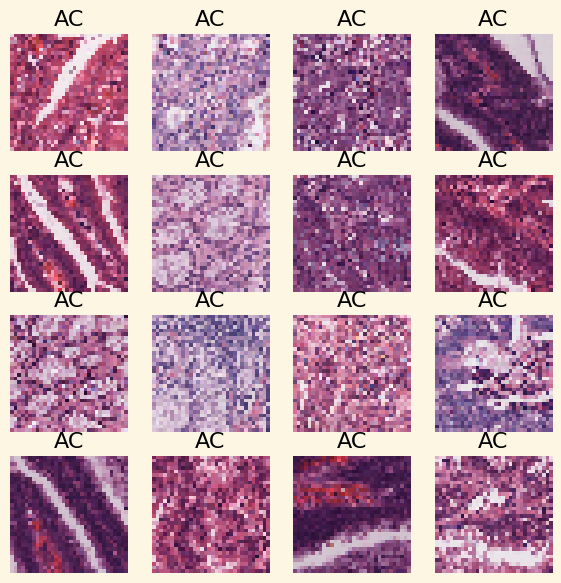

In [49]:
j = 0
fig, ax = plt.subplots(4, 4, figsize=(7, 7))
ax = ax.ravel()
for batch in train_ds.take(1):
    images = batch[0]
    labels = batch[1]
    for image, label in zip(images, labels):
        if j >= 16:
            break
        image = image.numpy().astype(np.uint8)
        ax[j].imshow(image)
        class_idx = np.argmax(label)
        class_name = train_ds.class_names[class_idx]
        ax[j].set_title(class_name)
        ax[j].axis("off")
        j += 1

# Assignment #2: dataset preparation
1.   Normalize images in the range [0, 1]
2.   Prepare the input pipeline via tf.data.Dataset methods



In [40]:
def process_data(image, label):
    return tf.cast(image, tf.float32) / 255., tf.one_hot(label, 3, name='label', axis=-1)

train_ds = train_ds.map(
    process_data, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.cache()
train_ds = train_ds.shuffle(2000)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

test_ds = test_ds.map(
    process_data, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.cache()
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

In [42]:
train_ds.take(1)

<_TakeDataset element_spec=(TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 3), dtype=tf.float32, name=None))>

# Assignment #3: train a VGG16 from scratch for 50 epochs


**Results:**

Accuracy: 0.75

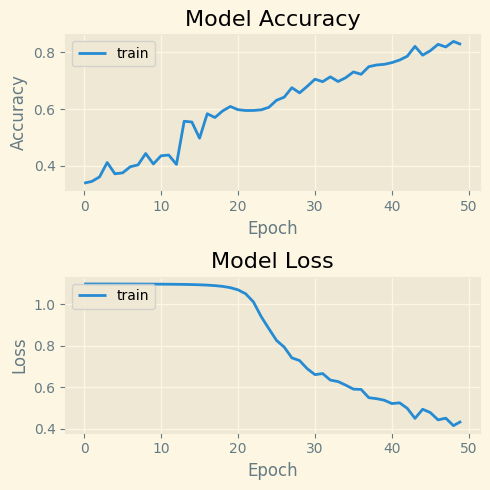

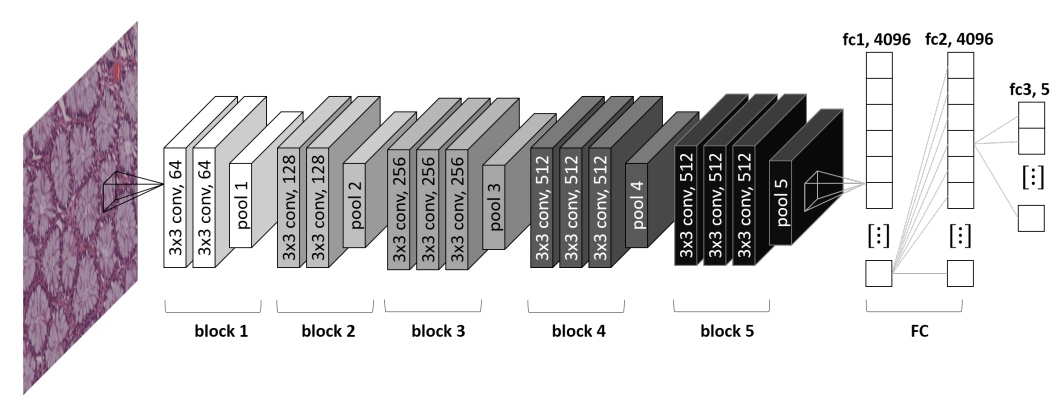

In [51]:
vgg16 = VGG16(
    include_top=True,
    weights=None,
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    classes=NUM_CLASSES,
    classifier_activation="softmax"
)


In [52]:
vgg16.compile(optimizer=tf.optimizers.SGD(0.01),
              metrics=["accuracy"],
              loss=tf.keras.losses.CategoricalCrossentropy())

history = vgg16.fit(train_ds, epochs=50)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 33s 97ms/step - accuracy: 0.3396 - loss: 1.0986
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.3456 - loss: 1.0985
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.3614 - loss: 1.0984
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.4122 - loss: 1.0983
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.3724 - loss: 1.0982
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.3758 - loss: 1.0981
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.3973 - loss: 1.0980
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - accuracy: 0.4038 - loss: 1.0979
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.4439 - loss: 1.0978
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy: 0.4071 - loss: 1.0976
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - accuracy: 0.4360 - loss: 1.0974
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - accuracy

In [54]:
print(f"Accuracy: {vgg16.evaluate(test_ds)[1]:.2f}")

36/36 ━━━━━━━━━━━━━━━━━━━━ 16s 347ms/step - accuracy: 0.7513 - loss: 0.6298
Accuracy: 0.75


## Plot train loss and accuracy among epochs (see [History](tf.keras.callbacks.History) object)

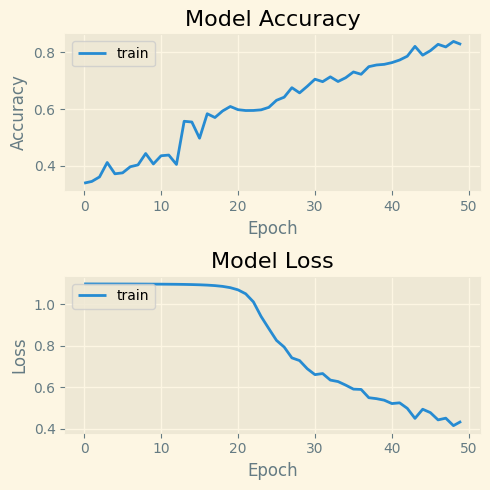

In [53]:
import matplotlib.pyplot as plt

plt.style.use("Solarize_Light2")
fig, ax = plt.subplots(2, 1, figsize=(5, 5))

# Plot Accuracy
ax[0].plot(history.history['accuracy'], label='train')
if 'val_accuracy' in history.history:
    ax[0].plot(history.history['val_accuracy'], label='test')
ax[0].set_title('Model Accuracy')
ax[0].set_ylabel('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend(loc='upper left')

# Plot Loss
ax[1].plot(history.history['loss'], label='train')
if 'val_loss' in history.history:
    ax[1].plot(history.history['val_loss'], label='test')
ax[1].set_title('Model Loss')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

# Assignment #4: extract features from VGG16 pre-trained on ImageNet and then train and test a downstream SVM.

Pipeline:
1. Features extraction from the CNN
2. PCA
3. SVM training and test

N.B. Do not shuffle train and test in order to extract labels in the correct order.


**Results**:

Test Accuracy: 0.83

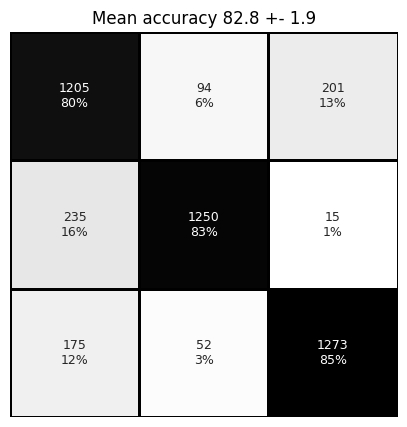

## Feature and labels Extraction

In [7]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{ROOTDIR_DATASET}/train",
    labels='inferred',
    label_mode='int',
    class_names=["AC", "AD", "H"],
    batch_size = 128,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{ROOTDIR_DATASET}/test",
    labels='inferred',
    label_mode='int',
    class_names=["AC", "AD", "H"],
    batch_size = 128,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
)

Found 9000 files belonging to 3 classes.
Found 4500 files belonging to 3 classes.


In [8]:
def process_data(image, label):
    image = tf.cast(image, tf.float32)
    return tf.keras.applications.vgg16.preprocess_input(image), label

train_ds = train_ds.map(
    process_data, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.cache()
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

test_ds = test_ds.map(
    process_data, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.cache()
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

In [9]:
vgg16 = VGG16(
    weights='imagenet',  # Load weights pre-trained on ImageNet.
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False
)
vgg16.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [23]:
x_train = vgg16.predict(train_ds).reshape(9000,-1)
x_test = vgg16.predict(test_ds).reshape(4500,-1)

71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


In [11]:
labels_train = np.concatenate([y for _, y in train_ds], axis=0)
labels_test = np.concatenate([y for _, y in test_ds], axis=0)

## SVM Pipeline

In [14]:
SEED = 42

In [15]:
from tempfile import mkdtemp
cachedir = mkdtemp()

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(svd_solver='full', n_components=0.95)),
    ('svc', SVC())
], memory=cachedir)

In [17]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV

param_distributions = {
    'svc__C': reciprocal(1, 1000),
    'svc__gamma': reciprocal(0.001, 1),
    'svc__kernel': ['rbf', 'linear'],
}

search = HalvingRandomSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    factor=3, resource='n_samples',
    random_state = SEED,
    # n_iter = 10,
    n_jobs = -1,
    cv = 3
)

In [18]:
search.fit(x_train, labels_train)

HalvingRandomSearchCV(cv=3,
                      estimator=Pipeline(memory='/tmp/tmpaxokhk22',
                                         steps=[('scaler', StandardScaler()),
                                                ('pca',
                                                 PCA(n_components=0.95,
                                                     svd_solver='full')),
                                                ('svc', SVC())]),
                      n_jobs=-1,
                      param_distributions={'svc__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7e627d756780>,
                                           'svc__gamma': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7e627d7564b0>,
                                           'svc__kernel': ['rbf', 'linear']},
                      random_state=42)

In [28]:
pred = search.predict(x_test)

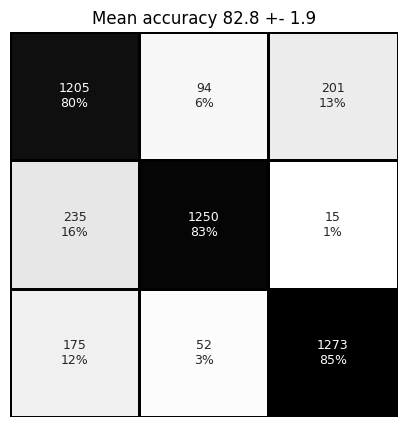

In [29]:
cm = confusion_matrix(labels_test, pred, labels=np.unique(labels_test))
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
seaborn_cm(cm, ax, ["AC", "AD", "H"], fontsize=9, xrotation=90)

# Assignment #5: Fine tune the VGG16 pre-trained on ImageNet.


**Results:**

Test Accuracy: 0.95

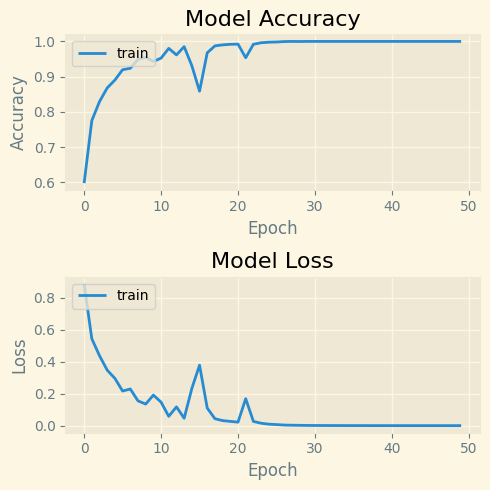

## Data Prep

In [36]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{ROOTDIR_DATASET}/train",
    labels='inferred',
    label_mode='int',
    class_names=["AC", "AD", "H"],
    batch_size = 128,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{ROOTDIR_DATASET}/test",
    labels='inferred',
    label_mode='int',
    class_names=["AC", "AD", "H"],
    batch_size = 128,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
)

Found 9000 files belonging to 3 classes.
Found 4500 files belonging to 3 classes.


In [37]:
def process_data(image, label):
    return tf.cast(image, tf.float32) / 255., tf.one_hot(label, 3, name='label', axis=-1)

train_ds = train_ds.map(
    process_data, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.cache()
train_ds = train_ds.shuffle(2000)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

test_ds = test_ds.map(
    process_data, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.cache()
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

In [41]:
train_ds.take(1)

<_TakeDataset element_spec=(TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 3), dtype=tf.float32, name=None))>

## Model

In [43]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
)

In [44]:
fine_tuned_model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(), # Reduces (8, 8, 512) to a vector of 512
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax') # Your 3 classes
])

In [45]:
fine_tuned_model.compile(optimizer=tf.optimizers.SGD(0.01),
              metrics=["accuracy"],
              loss=tf.keras.losses.CategoricalCrossentropy())

history = fine_tuned_model.fit(train_ds, epochs=50)

Epoch 1/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 43s 136ms/step - accuracy: 0.5978 - loss: 0.8864
Epoch 2/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.7753 - loss: 0.5433
Epoch 3/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.8293 - loss: 0.4373
Epoch 4/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.8680 - loss: 0.3471
Epoch 5/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.8904 - loss: 0.2957
Epoch 6/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.9197 - loss: 0.2165
Epoch 7/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.9238 - loss: 0.2293
Epoch 8/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.9489 - loss: 0.1550
Epoch 9/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.9550 - loss: 0.1351
Epoch 10/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.9433 - loss: 0.1911
Epoch 11/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.9526 - loss: 0.1470
Epoch 12/50
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accurac

## Eval

In [47]:
print(f"Accuracy: {fine_tuned_model.evaluate(test_ds)[1]:.2f}")

36/36 ━━━━━━━━━━━━━━━━━━━━ 17s 380ms/step - accuracy: 0.9460 - loss: 0.3178
Accuracy: 0.95


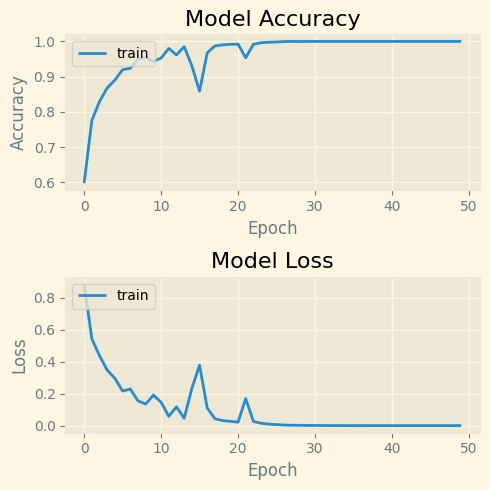

In [48]:
import matplotlib.pyplot as plt

plt.style.use("Solarize_Light2")
fig, ax = plt.subplots(2, 1, figsize=(5, 5))

# Plot Accuracy
ax[0].plot(history.history['accuracy'], label='train')
if 'val_accuracy' in history.history:
    ax[0].plot(history.history['val_accuracy'], label='test')
ax[0].set_title('Model Accuracy')
ax[0].set_ylabel('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend(loc='upper left')

# Plot Loss
ax[1].plot(history.history['loss'], label='train')
if 'val_loss' in history.history:
    ax[1].plot(history.history['val_loss'], label='test')
ax[1].set_title('Model Loss')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend(loc='upper left')

plt.tight_layout()
plt.show()